# **Clustering**
**Owner:** Ruth Mutheu

# **Online Shoppers Purchasing Intention Dataset**

## **Introduction**
This dataset used in this study is the Online Shoppers Purchasing Intention dataset obtained from from the UCI Machine Learning repository. It contains 12,330 records each representing the behavior of users on the e-commerce website during a one year period. Each record describes a single browsing session and includes 18 variables including numerical, categorical and binary attributes describing the browsing patterns of online shoppers.

The target variable, Revenue, indicates whether a purchase was completed in that session i.e True or False. Although clustering is unsupervised and does not use this label during model training, Revenue is later used to evaluate the behavioural differences between the identified clusters.

### **Objective**
The main objective of this project is to apply unsupervised learning techniques, specifically clustering algorithms, to the dataset in order to identify distinct groups of visitors based on their browsing behavior. By uncovering patterns and similarities in user activity such as the number and duration of pages visited, bounce and exit rates and traffic characteristics, the analysis aims to uncover behaviourally meaningful customer segments. These segments will then be examined to understand how they differ in terms of purchase likelihood, thereby providing insights that can support marketing and business decision-making.

### **Research Question**
Can clustering techniques uncover meaningful patterns in user sessions that explain differences in purchasing behavior among online shoppers?

### **Ethical and social considerations**
- The dataset contains no personal or identifiable user information. All data are collected at the session level and anonymized.
- It is compliant with data protection principles since it does not include demographic or personally identifiable data.
- The dataset was created for academic and research purposes and can be safely analyzed to derive behavioral insights without ethical concerns related to privacy or consent.
- Since the study focuses on aggregated behavioural patterns rather than personal characteristics, the risk of harm, discrimination or privacy violations is minimal.

## **Data Extraction**
Let us now begin this project by web scraping the data and check its structure.

In [1]:
#import libraries
import requests
import zipfile
import io
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#load dataset
url = 'https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip'

#download the zip file
r = requests.get(url)
r.raise_for_status()

#read zip file content
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    print("File inside zip:", z.namelist())
    
    #extract and read csv file
    with z.open("online_shoppers_intention.csv") as d:
        df = pd.read_csv(d)

#display the first and last five records
display(df.head())
display(df.tail())

File inside zip: ['online_shoppers_intention.csv']


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


## **Exploratory Data Analysis (EDA)**
Let us now explore the structure our dataset to gain insights into user behavior and website interactions. The goal is to understand the key patterns, relationships and distributions among features before applying clustering algorithms.

### **Dataset Exploration**

#### Dataset features
Let us describe the features to understand what each feature means.
1. *Administrative* - Number of pages visited in the administrative section of the website.
2. *Administrative_Duration* - Total time spent on administrative pages.
3. *Informational* - Number of pages viewed in the informational section.
4. *Informational_Duration* - Total time spent on informational pages.
5. *ProductRelated* - Number of product-related pages visited.
6. *ProductRelated_Duration* - Total time spent on product pages.
7. *BounceRates* - This represents the average bounce rate for the pages visited during the session.
8. *ExitRates* - Average exit rate of the visited pages.
9. *PageValues* - This represents the average value for a web page that a user visited before completing an e-commerce transaction.
10. *SpecialDay* - A number between 0 and 1  indicating the closeness of the site visiting time to a specific special day (e.g Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction.
11. *Month* - Month during which the session took place.
12. *OperatingSystems* - Numerical label representing the visitor’s operating system e.g Windows, Mac.
13. *Browser* - Numerical label representing the web browser used e.g Chrome, FireFox.
14. *Region* - Numerical code that indicates the geographical region of the visitor.
15. *TrafficType* - Categorical label for how the user arrived at the website e.g referral, adverts.
16. *VisitorType* - Indicates whether the user is a Returning Visitor, New Visitor or Other.
17. *Weekend* - It is True if the session occurred on a weekend and False otherwise.
18. *Revenue* - Target indicator showing whether the user completed a purchase in that session (True or False).

In [2]:
#check variable data types
df.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [3]:
#check for missing values
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [4]:
#check dimensions of the dataset
df.shape

(12330, 18)

In [5]:
#check for duplicate rows
df.duplicated().sum()

125

In [6]:
#drop duplicate rows
df = df.drop_duplicates()

In [7]:
#check dimension of the data after dropping duplicates
df.shape

(12205, 18)

#### **Identification of Variable Types and Summary Statistics**
Next, we define numerical, categorical and numerically encoded categorical columns separately as it is a clean way since they require different kinds of analysis during exploring of the data both in terms of statistical summary and visualization techniques.

In [8]:
#describe numerical features
num_cols = ['Administrative',
            'Administrative_Duration',
            'Informational',
            'Informational_Duration',
            'ProductRelated',
            'ProductRelated_Duration',
            'BounceRates',
            'ExitRates',
            'PageValues',
            'SpecialDay'
           ]

#descriptive statistics
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


#### **Interpretation of Descriptive Statistics**
From the summary statistics:
- Most users visit few or no administrative or informational pages, though a small segment explores them extensively.
- Product-related activity varies widely. Some users browse only a few products, while others view hundreds, indicating mixed purchase intentions.
- Session durations show large variability, suggesting different engagement levels, from quick visits to lengthy browsing sessions.
- Bounce and exit rates are generally low, implying that most visitors interact with multiple pages before leaving.
- Page values are highly skewed meaning most sessions contribute little revenue, but a few yield very high values, reflecting typical e-commerce behavior.
- Special days have minimal influence, as most sessions occur outside special event periods.
- Users access the site through diverse devices, browsers, regions and traffic sources, showing a broad and varied audience.

In [9]:
#check unique counts in each numerical column
for col in num_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")


Administrative: 27 unique values
Administrative_Duration: 3335 unique values
Informational: 17 unique values
Informational_Duration: 1258 unique values
ProductRelated: 311 unique values
ProductRelated_Duration: 9551 unique values
BounceRates: 1872 unique values
ExitRates: 4777 unique values
PageValues: 2704 unique values
SpecialDay: 6 unique values


In [10]:
#describe categorical features
cat_cols = ['Month',
            'VisitorType',
            'Weekend'
            ]

#summary statistics
df[cat_cols].describe().T

,count,unique,top,freq
Month,12205,10,May,3329
VisitorType,12205,3,Returning_Visitor,10431
Weekend,12205,2,False,9346


Here, we can see that majority of the sessions come from returning customers suggesting strong user familiarity with the website. Most browsing occur during weekdays and May stands out as a peak traffic month, indicating a potential marketing opportunity and sales campaigns.

In [11]:
#categorical variables represented numerically
cat_num_cols = ['OperatingSystems', 
                'Browser', 
                'Region',
                'TrafficType']

In [12]:
#check distribution of the class label
df['Revenue'].value_counts()

Revenue
False    10297
True      1908
Name: count, dtype: int64

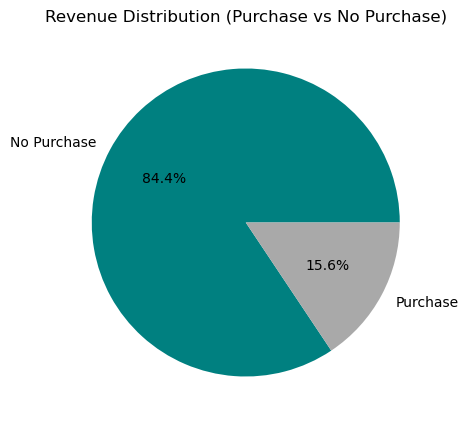

In [13]:
#visualize revenue distribution
plt.figure(figsize=(5,5))
df['Revenue'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['teal','darkgrey'], labels=['No Purchase','Purchase'])
plt.title("Revenue Distribution (Purchase vs No Purchase)")
plt.ylabel("")
plt.show()

From the results above, it is clear that the data is highly imbalanced with 84.4% of the sessions as non-purchasing sessions while only 15.6% of the sessions resulted in a complered purchase indicating a low conversion rate.

This indicates that a majority of visitors browse without buying.

### **Purchase Trends**
Let's now view the monthly trend analysis to discover the behavioural patterns.

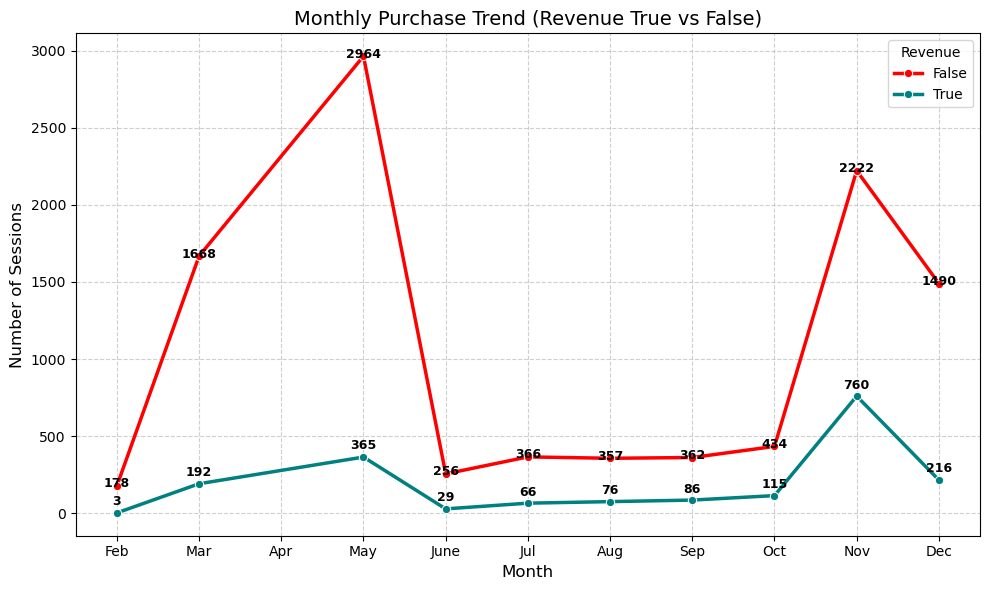

In [14]:
#convert month names to ordered categories
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

#group by Month and Revenue to count sessions
monthly_trend = df.groupby(['Month', 'Revenue'], observed=True).size().reset_index(name='Count')

#plotting the lines
plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_trend, x='Month', y='Count', hue='Revenue', marker='o',
             palette=['red','teal'], linewidth=2.5)

plt.title("Monthly Purchase Trend (Revenue True vs False)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Sessions", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

#auto-adjusted label placement
for revenue_val in monthly_trend['Revenue'].unique():
    subset = monthly_trend[monthly_trend['Revenue'] == revenue_val]
    for i, row in subset.iterrows():
        #apply small vertical offset based on Revenue
        y_offset = 0.01 * monthly_trend['Count'].max() if revenue_val else -0.01 * monthly_trend['Count'].max()
        plt.text(row['Month'], row['Count'] + y_offset,
                 f"{int(row['Count'])}",
                 ha='center', va='bottom', fontsize=9,
                 color='black', fontweight='semibold')

plt.tight_layout()
plt.show()

#### **Purchase Trend Insights**
- Most sessions do not result in a purchase, regardless of month which aligns with the overall low conversion rate of the dataset.
- Peak months include May and November, with the highest session counts and notable increases in purchases, likely linked to seasonal promotions or marketing campaigns.
- The purchase trend generally follows the same shape as the non-purchase trend indicating that factors increasing site traffic tend to also increase conversions.
- Purchase ratios fluctuate across months, with November showing a relatively higher conversion rate, indicating effective campaigns or seasonal buying trends.

### **Correlation Heatmap**

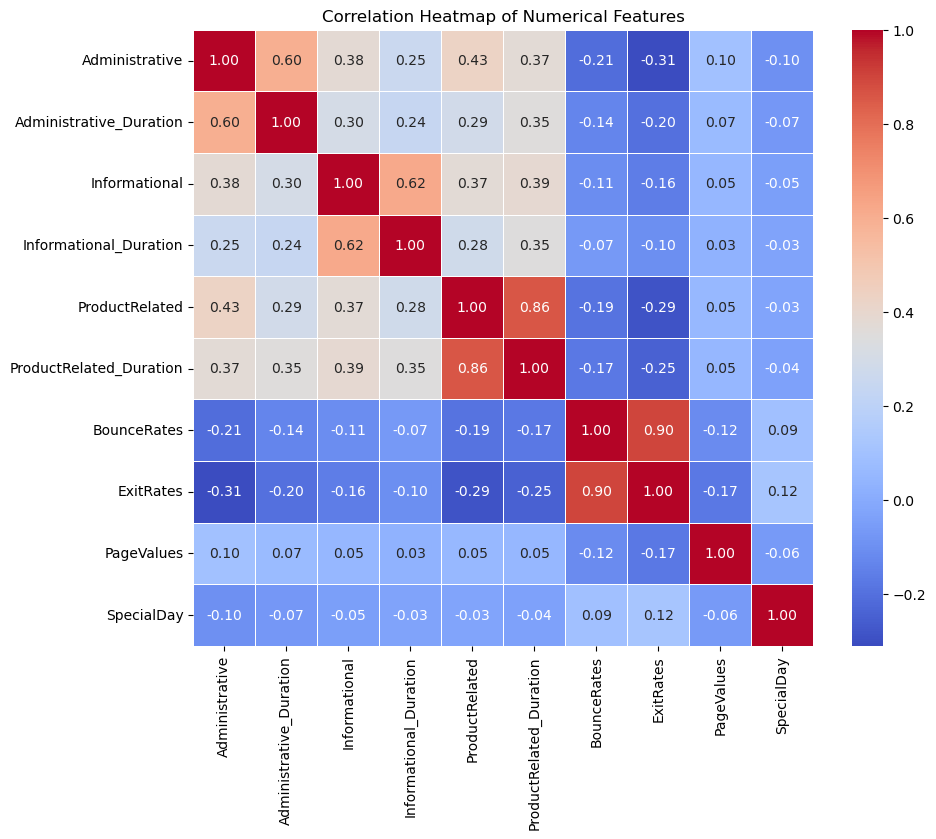

In [15]:
#correlation heatmap for numerical features
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#### **Result Interpretation**
- Page counts and time spent are strongly related, such as ProductRelated and ProductRelated_Duration (0.86), and Administrative and Administrative_Duration (0.60).
-BounceRates and ExitRates are highly correlated (0.90), indicating that sessions with high bounce behaviour also tend to have high exit behaviour.
- Most other variables show weak or minimal correlation, meaning they capture different aspects of user behaviour and contribute unique information.
- SpecialDay and PageValues exhibit almost no correlation with other features suggesting independent behavioural effects.
- Negative correlations are mild and behaviourally consistent for instance higher bounce rates occur in sessions with fewer page visits.

### **Detection of Outliers**
We need to understand the spread and presence of outliers for each numerical feature.

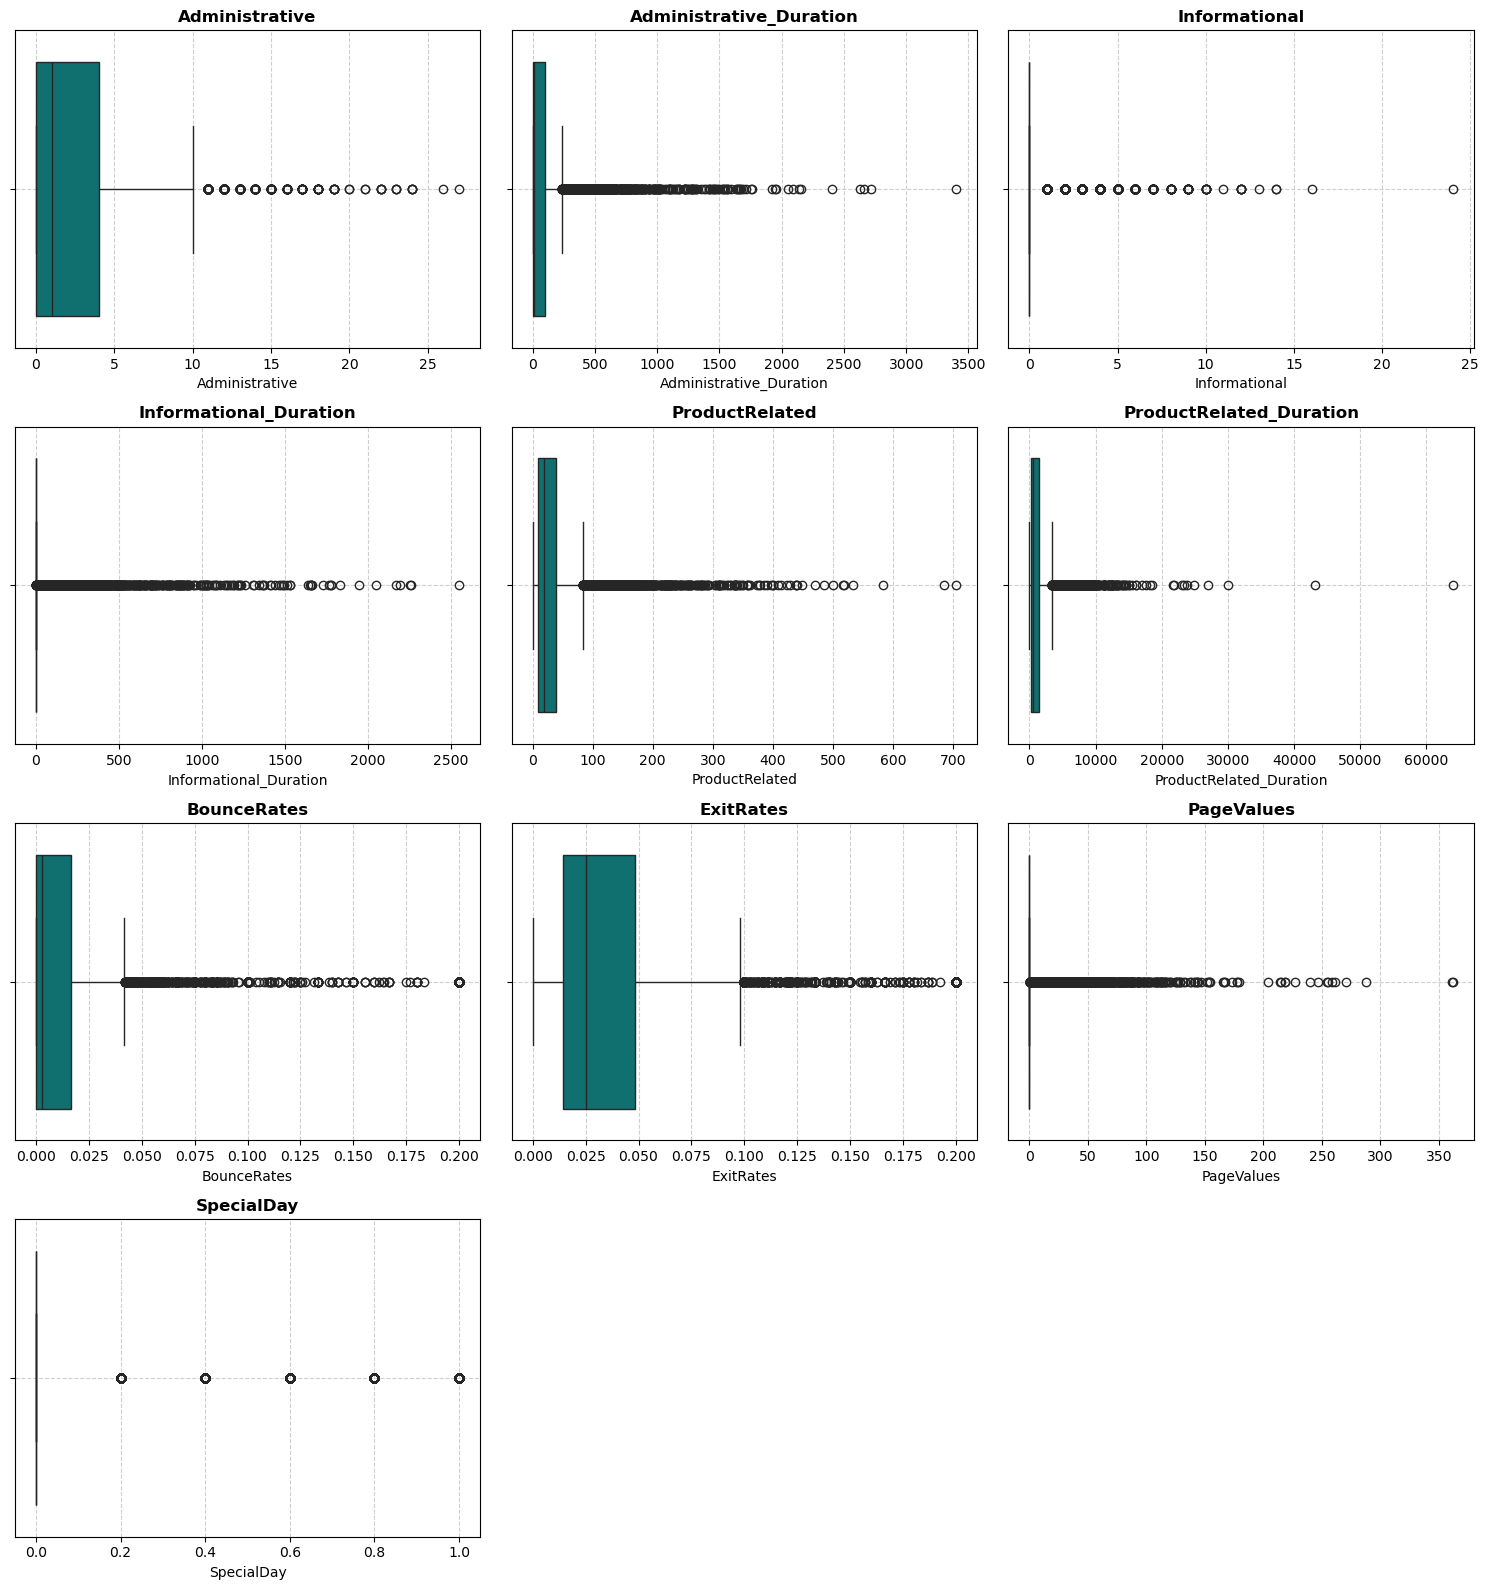

In [16]:
#individual boxplots for each numerical column
import math

num_features = len(num_cols)
cols = 3  #number of plots per row
rows = math.ceil(num_features / cols)

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[col], color='teal')
    plt.title(col, fontsize=12, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### **Result Interpretation**
- Administrative, Informational and Product-Related page counts all show many low-activity sessions with a few users visiting unusually high numbers of pages, creating outliers.
- Duration features i.e Administrative_Duration, Informational_Duration and ProductRelated_Duration have extreme long-tailed outliers, reflecting sessions where users spent very long periods browsing.
- BounceRates and ExitRates are generally low for most users but a minority show high early-exit behavior, forming upper outliers.
- PageValues is heavily concentrated at zero, with a few sessions receiving very high value scores, indicating strong purchase intent.
- SpecialDay is mostly zero, showing it is a rare event feature with few non-zero points.

In [17]:
#count outliers per column using IQR
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR)))
outlier_counts = outliers.sum().sort_values(ascending=False)
outlier_summary = pd.DataFrame({'Feature': outlier_counts.index,
                                'Outlier Count': outlier_counts.values,
                                'Outlier %': np.round((outlier_counts.values/len(df))*100,2)})
display(outlier_summary)

,Feature,Outlier Count,Outlier %
0,PageValues,2730,22.37
1,Informational,2631,21.56
2,Informational_Duration,2405,19.71
3,BounceRates,1428,11.70
4,ExitRates,1325,10.86
5,SpecialDay,1249,10.23
6,Administrative_Duration,1149,9.41
7,ProductRelated,1007,8.25
8,ProductRelated_Duration,951,7.79
9,Administrative,404,3.31


Overall, the high values reflect the naturally skewed behavior of online user sessions where a small number of visitors view many pages, spend long durations on specific sections or exhibit unusually high bounce and exit rates. These outliers represent valid behavioural patterns and therefore instead of removing or capping them, we will apply RobustScaler to reduce their impact before clustering.

### **Distribution of Numerical Variables**
Let's now plot histograms to check the non-normal distributions and high variability in user behavior as seen in the boxplots.

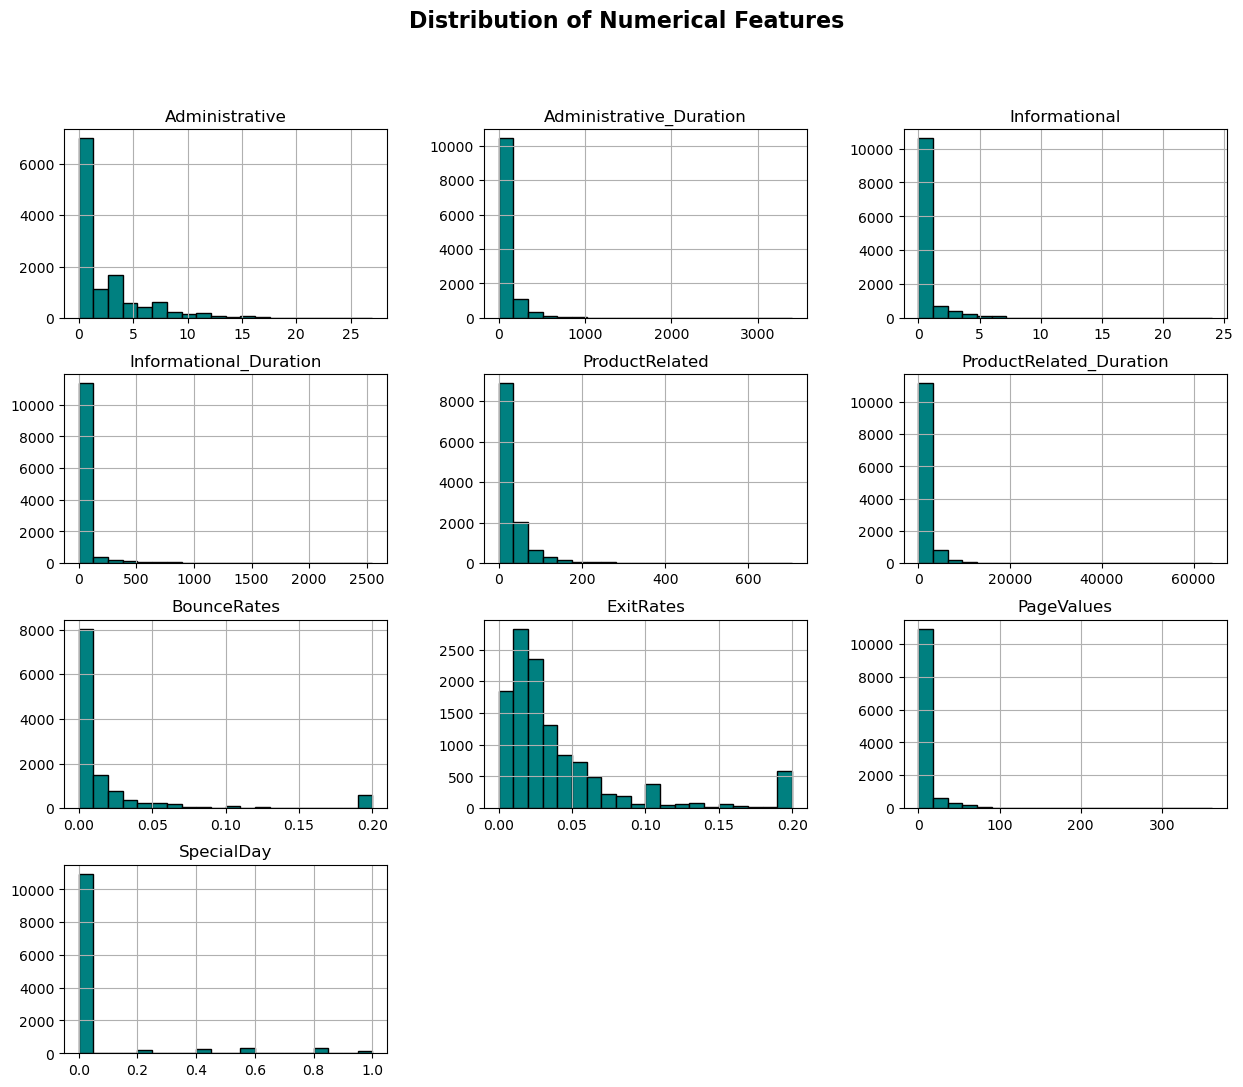

In [18]:
df[num_cols].hist(bins=20, figsize=(15, 12), color='teal', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

#### **Result Interpretation**
- Most features like Administrative_Duration, Informational_Duration, ProductRelated_Duration show a right skewness indicating that while most sessions have low values, a few sessions have extremely high values representing highly engaged users
- BounceRates, ExitRates and PageValues are also right skewed suggesting that most user sessions have low bounce and exit rates and that most users do not immediately leave after a single page.
- SpecialDay distribution show that most sessions occur far from special days.

### **Visitor type behavior**
Let us now check the percentage of sessions that resulted in a purchase for each visitor type, along with the total number of visitors in each group and then compare engagement metrics per visitor type.

In [19]:
#visitor counts
visitor_counts = df['VisitorType'].value_counts().rename('Number of visitors')

#purchase percentages
visitor_purchase = pd.crosstab(df['VisitorType'], df['Revenue'], normalize='index') * 100
visitor_purchase.columns = ['No Purchase %', 'Purchase %']
visitor_purchase = visitor_purchase.round(2)

#merge both
visitor_summary = visitor_purchase.merge(visitor_counts, left_index=True, right_index=True)

display(visitor_summary)

,No Purchase %,Purchase %,Number of visitors
VisitorType,,,
New_Visitor,75.07,24.93,1693
Other,80.25,19.75,81
Returning_Visitor,85.91,14.09,10431


#### **Result Interpretation**
- Returning visitors form the largest segment, showing loyalty and repeated engagement but their conversion rate is relatively low, perhaps because they browse often but only occasionally buy.
- New Visitors have the highest purchase rate (24.93%), indicating that first-time users are more likely to complete a transaction in a single session than returning users e.g they maybe attracted by promotions or first impressions.
- Other is a small group with moderate purchase behaviour but the group is too small to influence overall trends.

In [20]:
#aggregate mean per visitor type
visitor_metrics = df.groupby('VisitorType')[num_cols].mean()
visitor_metrics

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
VisitorType,,,,,,,,,,
New_Visitor,2.553455,91.965604,0.333727,19.248835,18.064973,636.769251,0.005146,0.020575,10.778550,0.020201
Other,1.543210,65.791667,0.185185,12.262551,13.037037,598.573004,0.030579,0.056600,19.090173,0.000000
Returning_Visitor,2.310229,80.094581,0.539641,37.528820,34.462372,1304.255214,0.022762,0.044739,5.063768,0.069198


#### **Result Interpretation**
- Returning visitors show the highest average interactions across almost all engagement metrics. They have the greatest number of product-related visits (34.46) and the longest average product-related duration (1304.26 seconds). This suggests that returning users are more actively engaged and tend to spend more time exploring products, which may indicate a stronger purchase intent or familiarity with the website.
- New visitors interact less with product-related and informational pages compared to returning visitors but still maintain moderate engagement levels. Their bounce and exit rates are the lowest, suggesting they tend to explore more pages before leaving. This indicates potential curiosity or exploration behavior as they navigate the site for the first time.
- Other shows the least engagement overall. They record the lowest values in product-related, administrative and informational activity but have the highest bounce and exit rates, implying limited interest and quicker drop-offs. Interestingly, their page value is the highest but due to a very small sample size, this category is not strongly representative.

### Distribution of Numerically Encoded Categorical Features

In [21]:
cat_summary = {}
for col in cat_num_cols:
    counts = df[col].value_counts()
    purchase_rate = pd.crosstab(df[col], df['Revenue'], normalize='index') * 100
    summary = pd.concat([counts, purchase_rate], axis=1)
    summary.columns = ['Count', 'No Purchase %', 'Purchase %']
    cat_summary[col] = summary.round(2)

# Display summaries
for col, table in cat_summary.items():
    print(f"\nSummary for {col}:")
    display(table)



Summary for OperatingSystems:


,Count,No Purchase %,Purchase %
OperatingSystems,,,
2,6541,82.34,17.66
1,2549,85.13,14.87
3,2530,89.41,10.59
4,478,82.22,17.78
8,75,77.33,22.67
6,19,89.47,10.53
7,7,85.71,14.29
5,6,83.33,16.67



Summary for Browser:


,Count,No Purchase %,Purchase %
Browser,,,
2,7883,84.49,15.51
1,2427,84.96,15.04
4,731,82.22,17.78
5,465,81.51,18.49
6,174,88.51,11.49
10,163,80.37,19.63
8,135,84.44,15.56
3,105,95.24,4.76
13,56,71.43,28.57



Summary for Region:


,Count,No Purchase %,Purchase %
Region,,,
1,4714,83.64,16.36
3,2379,85.33,14.67
4,1171,85.06,14.94
2,1128,83.33,16.67
6,801,86.02,13.98
7,758,84.30,15.70
9,505,82.97,17.03
8,431,87.01,12.99
5,318,83.65,16.35



Summary for TrafficType:


,Count,No Purchase %,Purchase %
TrafficType,,,
2,3911,78.34,21.66
1,2388,89.03,10.97
3,2013,91.06,8.94
4,1066,84.52,15.48
13,728,94.09,5.91
10,450,80.00,20.00
6,443,88.04,11.96
8,343,72.30,27.70
5,260,78.46,21.54


#### Result Interpretation
- Although Operating System 2 accounts for the majority of traffic, some smaller OS groups e.g OS 8 show higher purchase percentages. While these categories represent small samples, they highlight the value of ensuring strong compatibility and performance across all devices not only the dominant ones.
- Conversion behavior varies strongly across browsers, tailoring site compatibility and marketing focus toward high-performing browsers could improve conversions.
- Regional differences suggest varying customer intent and market potential. Regions 1, 2 and 9 could be prioritized for promotions or localized campaigns as they show slightly stronger buying intent..
- Certain referral or ad sources drive high-value customers like types 7, 8, 16, 20, while others bring volume with little return. This segmentation can guide advertising budget reallocation allowing the business to invest more in high-performing traffic channels.

## **Data Preprocessing**
Before applying clustering algorithms, we need to preprocess the data to ensure that all features are in a suitable format for analysis. This involves handling categorical variables, scaling numerical features and preparing the data in a way that supports distance-based clustering methods.

### **Feature Selection and Separation**

In [22]:
#separate features and target
target_col = "Revenue"

y_revenue = df[target_col].astype(int) #convert boolean target to integer
X = df.drop(columns=[target_col])

In [23]:
#define numerical and categorical fetures
numeric_features = num_cols
categorical_features = cat_cols + cat_num_cols

print(numeric_features)
print(categorical_features)

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


### **Scaling Numerical Features**
From our exploratory data analysis, it is evident that numerical features in our data contain many outliers. These extreme values represent real user behaviour eg very long browsing sessions. We do not consider outliers as data errors and for this reason, we cannot remove them as doing so would disregard meaningful information.

To ensure that these extreme values do not distort distance-based clustering algorithms, we will scale the numerical features using RobustScaler, which relies on the median and interquartile range (IQR). This makes it far less sensitive to outliers while preserving the full behavioural variation present in the dataset.

In [24]:
#use RobustScaler on numeric columns to reduce outliers
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler())
])

### **Encoding categorical variables (One-Hot Encoding)**

In [25]:
#OneHotEncoder for categorical columns
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

### **Building the preprocessing pipeline and transforming the data**

In [26]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        #apply numeric pipeline to numeric features
        ('num', numeric_transformer, numeric_features),

        #apply categorical pipeline to categorical features
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [27]:
#fit the preprocessor and transform X
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(12205, 75)


### **Principal Component Analysis (PCA)**
In this project, we perform clustering on the full high-dimensional dataset (X_processed), which contains many features after scaling and one-hot encoding. However, high-dimensional data cannot be plotted directly and visualising the structure of the dataset is important for understanding how well the clusters separate.

To address this, we apply Principal Component Analysis (PCA) to help us understand the structure of the data and evaluate cluster separation.

In [28]:
from sklearn.decomposition import PCA

#fit PCA on the processed data and transform it to 2D
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X_processed)

print("PCA 2D explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by PC1+PC2:", pca.explained_variance_ratio_.sum())

PCA 2D explained variance ratio: [0.98184025 0.01707327]
Total variance explained by PC1+PC2: 0.9989135262459595


#### **Result Interpretation**
PCA shows that the two principal components capture 99.89% of the total variance in the dataset, with the first principal component explaining the vast majority (98.18%). This means the 2D PCA projection is an almost perfect representation of the original high-dimensional data.

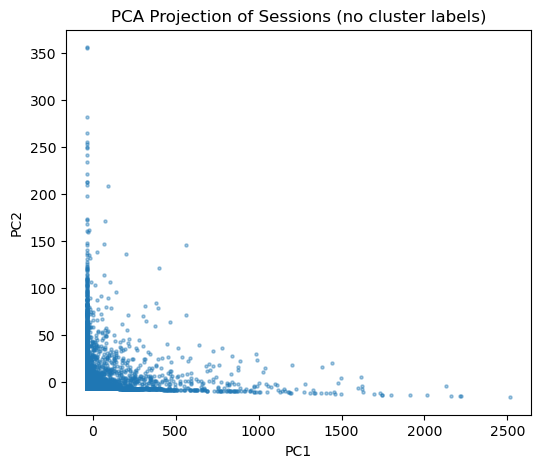

In [29]:
#visualizing sessions in PCA space (no clusters)
plt.figure(figsize=(6,5))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], s=5, alpha=0.4)
plt.title("PCA Projection of Sessions (no cluster labels)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

#### **Interpretation of the PCA Scatter Plot**
The PCA scatter plot shows that most user sessions are low activity and cluster tightly near the origin. A smaller number of highly engaged users extend far along PC1, which captures 98% of the variance. The triangular shape indicates that low-engagement users behave variably, while high-engagement users follow more consistent patterns.

## **Clustering Analysis**

### **Clustering Evaluation**
Let's define evaluate_clustering() function that computes three internal validation metrics i.e Silhouette Score, Davies–Bouldin Index and Calinski–Harabasz Score, to objectively measure cluster quality. These metrics assess cluster compactness and separation without requiring true labels, making them ideal for comparing our algorithms.

In [30]:
#clustering evaluation 
def evaluate_clustering(X_data, labels, name="Clustering"):
    unique_labels = np.unique(labels)
    if len (unique_labels) < 2:
        print(f"\n {name}")
        print("Not enough clusters to compute internal metrics")
        return None, None, None

    sil = silhouette_score(X_data, labels)
    db = davies_bouldin_score(X_data, labels)
    ch = calinski_harabasz_score(X_data, labels)

    print(f"\n {name}")
    print("Silhouette score        (higher is better):", round(sil, 4))
    print("Davies–Bouldin index    (lower is better):", round(db, 4))
    print("Calinski–Harabasz score (higher is better):", round(ch, 2))
    
    return sil, db, ch

## **K-Means Clustering**
We will select K-Means clustering because it is highly effective for identifying structure in large, high-dimensional behavioural datasets like our dataset. The algorithm performs particularly well when clusters are expected to be compact, distinct and roughly spherical, assumptions that align well with our preprocessed data after scaling and one-hot encoding.

### **Finding the Optimal Number of Clusters**
Let us begin by running the loop below to test different numbers of clusters and see which one works best. For each possible value of k, the code creates a temporary K-Means model, groups the data and measures how good the grouping looks. By comparing the results across all options, we can identify the number of clusters that gives the clearest and most meaningful separation of user sessions before choosing a final model.

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)

k_values = range(2, 11)
inertias = []
sil_scores = []
db_scores = []

#loop through k=2 to 10 and evaluate clustering performance
for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_temp = kmeans_temp.fit_predict(X_processed)

    #store metr
    inertias.append(kmeans_temp.inertia_)
    sil_scores.append(silhouette_score(X_processed, labels_temp))
    db_scores.append(davies_bouldin_score(X_processed, labels_temp))

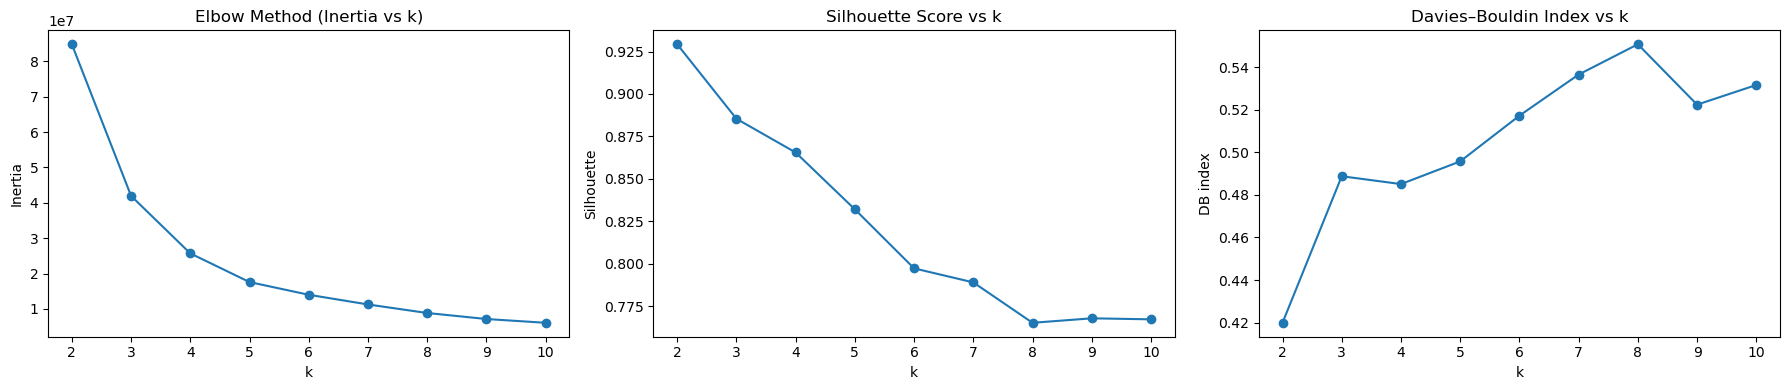

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

#elbow plot
axes[0].plot(k_values, inertias, marker='o')
axes[0].set_title("Elbow Method (Inertia vs k)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

#silhouette plot
axes[1].plot(k_values, sil_scores, marker='o')
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

#davies-bouldin plot
axes[2].plot(k_values, db_scores, marker='o')
axes[2].set_title("Davies–Bouldin Index vs k")
axes[2].set_xlabel("k")
axes[2].set_ylabel("DB index")

plt.tight_layout()
plt.show()

#### **Result Interpretation**
From the results above, we select k=4 as the optimal number of clusters for K-Means. This is because it offers a strong compromise across inertia, silhouette and DB-index and provides more meaningful segmentation while maintaining good clustering quality.

### **Fitting the Final K-Means Model**
Based on our evaluation metrics, let us now fit the final model.

In [33]:
#choose optimal k
optimal_k = 4   #chosen from elbow + silhouette + DB index
print(f"\nChosen k for K-Means: {optimal_k}")

#fit final K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)
kmeans_labels = kmeans.fit_predict(X_processed)

#evaluate final model using our evaluation function
kmeans_sil, kmeans_db, kmeans_ch = evaluate_clustering(
    X_processed,
    kmeans_labels,
    name=f"K-Means (k={optimal_k})"
)

df['KMeans_Cluster'] = kmeans_labels


Chosen k for K-Means: 4

 K-Means (k=4)
Silhouette score        (higher is better): 0.8704
Davies–Bouldin index    (lower is better): 0.4759
Calinski–Harabasz score (higher is better): 35310.59


#### **Evaluating the K-Means Performance**
The final K-Means model with 4 clusters performed very well:
- The high silhouette score shows that the customers within each cluster are similar to each other, while being different from customers in other clusters.
- The low Davies–Bouldin index confirms that the clusters are well-separated and not overlapping too much.
- The high Calinski–Harabasz score further indicates that the clusters are well-structured.

Overall, these results suggest that choosing 4 clusters provides a meaningful and reliable way to group user sessions based on their browsing behaviour.

### **Visualizing K-Means Clusters**

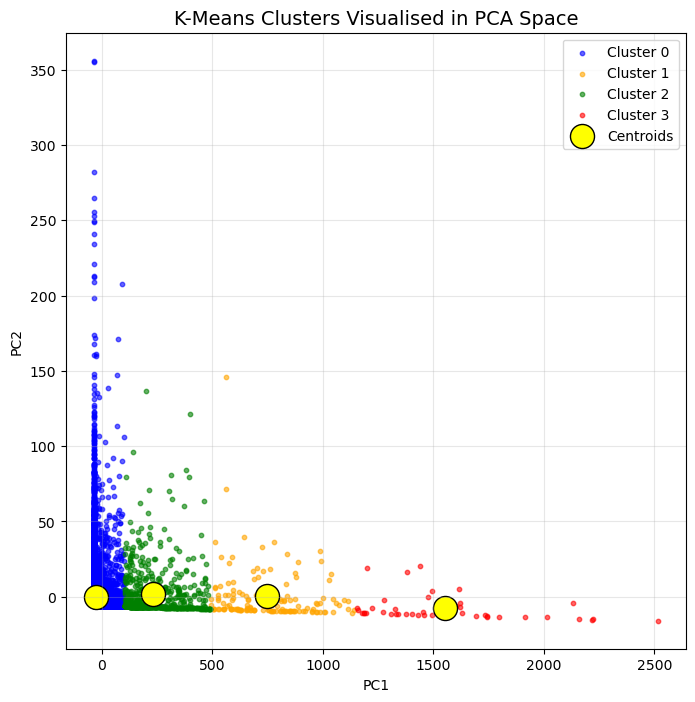

In [34]:
#K-Means cluster visualisation in PCA space
plt.figure(figsize=(8,8))

#plot each cluster separately with different colours
plt.scatter(X_reduced[kmeans_labels == 0, 0], X_reduced[kmeans_labels == 0, 1],
            s=10, c='blue', label='Cluster 0', alpha=0.6)

plt.scatter(X_reduced[kmeans_labels == 1, 0], X_reduced[kmeans_labels == 1, 1],
            s=10, c='orange', label='Cluster 1', alpha=0.6)

plt.scatter(X_reduced[kmeans_labels == 2, 0], X_reduced[kmeans_labels == 2, 1],
            s=10, c='green', label='Cluster 2', alpha=0.6)

plt.scatter(X_reduced[kmeans_labels == 3, 0], X_reduced[kmeans_labels == 3, 1],
            s=10, c='red', label='Cluster 3', alpha=0.6)

#plot cluster centroids (but centroids must also be projected into PCA space)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=300, c='yellow', edgecolor='black', label='Centroids')

#formatting
plt.title('K-Means Clusters Visualised in PCA Space', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **Interpreting K-Means Results**
This PCA scatter plot shows how the four K-Means clusters are separated when the high-dimensional data is reduced to two principal components. The clusters form clear groups:
- Cluster 0 contains users with very low overall activity, short sessions and few page interactions.
- Cluster 2 shows slightly more engaged users with moderate browsing activity.
- Cluster 1 represents users with higher browsing levels i.e more pages and longer duration.
- Cluster 3 contains the most active users indicating long sessions, many product-related interactions and high page values.

Even though PCA reduces the data to only two dimensions, the clusters appear well-separated, which supports the earlier quantitative results showing strong K-Means performance. This visualisation confirms that our model has picked up meaningful patterns in user browsing behaviour.

## **Agglomerative Hierarchical Clustering**
Next, let us use Agglomerative Hierarchical Clustering to validate the customer segments found earlier with K-Means. This method builds clusters step-by-step by initially treating every session as its own cluster and then repeatedly merging the most similar pairs unlike K-Means which requires selecting the number of clusters in advance.

### **Generating the Dendrogram**
Let us visually understand the natural grouping structure in our dataset before choosing the number of clusters.

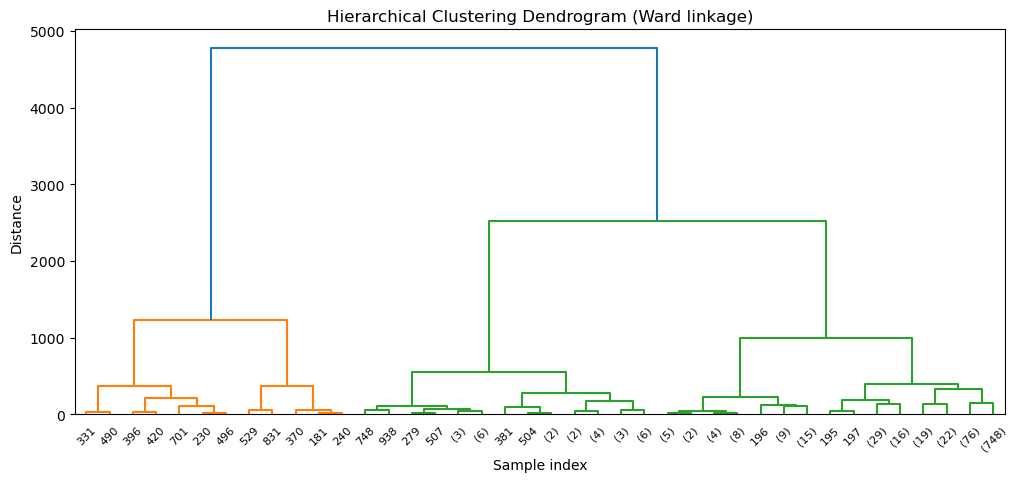

In [35]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

sample_size = 1000  # use up to 1000 points
X_sample = X_processed[:sample_size]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

#### **Dendrogram Interpretation**
The dendrogram shows that the browsing sessions fall into roughly four well-separated groups. These groups differ mainly in engagement level, browsing depth and shopping intent.

### **Fitting the Model**
After identifying the four clusters, we need to fit the model.

In [36]:
n_clusters_h = 4

hc = AgglomerativeClustering(
    n_clusters=n_clusters_h,
    linkage='ward'
)

hc_labels = hc.fit_predict(X_processed)
df['HC_Cluster'] = hc_labels

### **Evaluating Hierarchical Clustering**
Next, we need to measure how well our model performed.

In [37]:
hc_sil, hc_db, hc_ch = evaluate_clustering(
    X_processed,
    hc_labels,
    name=f"Hierarchical (Ward, k={n_clusters_h})"
)


 Hierarchical (Ward, k=4)
Silhouette score        (higher is better): 0.876
Davies–Bouldin index    (lower is better): 0.4507
Calinski–Harabasz score (higher is better): 34069.69


#### **Interpretation of Hierarchical Clustering Results**
The hierarchical model with four clusters achieves very strong performance across all evaluation metrics:
- The silhouette score of 0.876 indicates that sessions within the same cluster are highly similar while being very well separated from other clusters.
- The low Davies–Bouldin index (0.4507) further confirms good separation between the groups.
- The high Calinski–Harabasz score (34,069) shows that the clusters are compact and well-defined.

Overall, these results demonstrate that hierarchical clustering successfully identifies four meaningful and distinct behavioural segments in the dataset, closely matching the structure discovered by K-Means.

### **Visualizing Hierarchical Clusters**

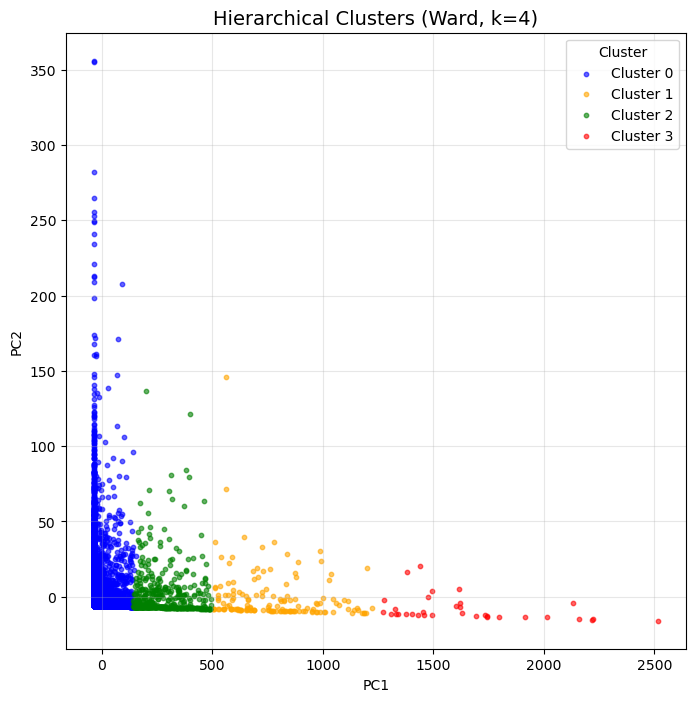

In [38]:
#manual cluster-by-cluster plotting for Hierarchical Clustering in PCA space
plt.figure(figsize=(8,8))

plt.scatter(X_reduced[hc_labels == 0, 0], X_reduced[hc_labels == 0, 1],
            s=10, c='blue', label='Cluster 0', alpha=0.6)

plt.scatter(X_reduced[hc_labels == 1, 0], X_reduced[hc_labels == 1, 1],
            s=10, c='orange', label='Cluster 1', alpha=0.6)

plt.scatter(X_reduced[hc_labels == 2, 0], X_reduced[hc_labels == 2, 1],
            s=10, c='green', label='Cluster 2', alpha=0.6)

plt.scatter(X_reduced[hc_labels == 3, 0], X_reduced[hc_labels == 3, 1],
            s=10, c='red', label='Cluster 3', alpha=0.6)

#formatting
plt.title(f"Hierarchical Clusters (Ward, k={n_clusters_h})", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title='Cluster')
plt.grid(alpha=0.3)
plt.show()

#### **Interpreting the Hierarchical Clustering Plot**
The patterns are very similar to the K-Means clustering results, which indicates that the data has a strong and consistent natural structure. The clusters can be interpreted as follows:
- Cluster 0 (blue) – users with low engagement e.g short sessions, few pages visited and low product interaction.
- Cluster 1 (orange) – moderately engaged users with slightly higher interaction and browsing depth.
- Cluster 2 (green) – higher engagement users with more product-related activity and longer visit durations.
- Cluster 3 (red) – the most engaged users: long sessions, many page interactions and higher page values indicating strong purchase interest.

The clear separation between clusters suggests that hierarchical clustering identifies distinct patterns of browsing behaviour, reinforcing the same groups discovered by K-Means. This consistency across two different algorithms increases confidence that these segments represent meaningful, stable customer behaviours useful for business insights.

### **Cluster Profiling**
Let's analyse the characteristics of each group to understand how they differ in behaviour and purchase intent.


Hierarchical cluster profile (means & conversion rate):


Administrative Administrative_Duration Informational  \
                     mean                    mean          mean   
HC_Cluster                                                        
0                   2.126                  72.425         0.321   
1                   6.358                 237.827         4.232   
2                   5.900                 228.612         3.554   
3                   6.424                 444.851         4.576   

           Informational_Duration ProductRelated ProductRelated_Duration  \
                             mean           mean                    mean   
HC_Cluster                                                                 
0                           8.770         29.493                1087.129   
1                         807.624         88.344                3890.661   
2                         303.949         68.654                2760.155   
3                        1678.633        132.212                8150.261   

           BounceRates ExitRates PageValues SpecialDay Revenue         
                  mean      mean       mean       mean    mean  count  
HC_Cluster                                                             
0                0.021     0.043      5.803      0.064   0.149  11539  
1                0.008     0.022      9.071      0.028   0.305    151  
2                0.007     0.021      8.573      0.029   0.280    482  
3                0.007     0.026      4.729      0.067   0.212     33

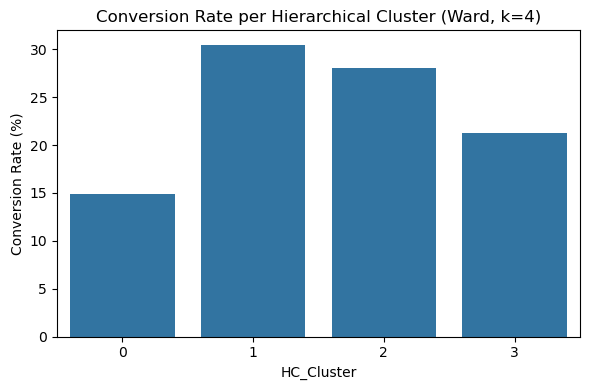

In [39]:
hc_profile = df.groupby('HC_Cluster').agg({
    'Administrative': 'mean',
    'Administrative_Duration': 'mean',
    'Informational': 'mean',
    'Informational_Duration': 'mean',
    'ProductRelated': 'mean',
    'ProductRelated_Duration': 'mean',
    'BounceRates': 'mean',
    'ExitRates': 'mean',
    'PageValues': 'mean',
    'SpecialDay': 'mean',
    'Revenue': ['mean', 'count']
}).round(3)

print("\nHierarchical cluster profile (means & conversion rate):")
display(hc_profile)

# Conversion rate per HC cluster
hc_conv = df.groupby('HC_Cluster')['Revenue'].mean().reset_index()
hc_conv['Revenue'] = hc_conv['Revenue'] * 100

plt.figure(figsize=(6,4))
sns.barplot(data=hc_conv, x='HC_Cluster', y='Revenue')
plt.title("Conversion Rate per Hierarchical Cluster (Ward, k=4)")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.show()

#### **Result Interpretation**
Hierarchical clustering reveals clear behavioural segmentation:
- Clusters 1 and 2 represent the most commercially valuable users, showing high engagement and high conversion rates.
- Cluster 0 is the main volume of casual visitors, with moderate conversion.
- Cluster 3 contains hyper-engaged but inconsistent buyers which is a potential opportunity for remarketing or targeted promotions.

These behavioural differences provide valuable insight into customer intent and can guide personalised marketing, session optimisation and targeted interventions.

## **Comparison of Clustering Algorithms**
Let us now compare the performance of our clustering algorithms using three evaluation metrics.


Comparison of clustering algorithms:


,Algorithm,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,0.870396,0.47587,35310.593866
1,Hierarchical,0.876021,0.45065,34069.690879


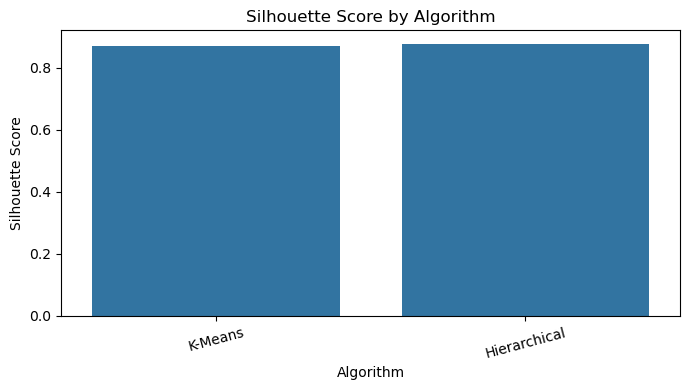

In [40]:
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical'],
    'Silhouette': [kmeans_sil, hc_sil],
    'Davies_Bouldin': [kmeans_db, hc_db],
    'Calinski_Harabasz': [kmeans_ch, hc_ch]
})

print("\nComparison of clustering algorithms:")
display(comparison)


#plot silhouette comparison
plt.figure(figsize=(7,4))
sns.barplot(data=comparison, x='Algorithm', y='Silhouette')
plt.title("Silhouette Score by Algorithm")
plt.ylabel("Silhouette Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### **Result Interpretation**
- Agglomerative Hierarchical Clustering performs the best overall indicating very compact and well separated clusters.
- K-Means performs almost equally well with the results closely matching hierarchical clustering.

Therefore, the behavioural structure in the online shopper dataset is well captured by K-Means and Hierarchical clustering.

## **Evaluation of the Output**
Both K-Means and Hierarchical Clustering produced four well-defined and clearly separated clusters, each reflecting a distinct browsing behaviour profile. Internal evaluation metrics confirmed the strength of these models, both achieving high silhouette scores and low Davies–Bouldin indices, highlighting excellent cohesion within clusters and strong separation between them.

### **Business Insights and Recommendations**
Based on the four behavioural clusters we identified, the following actions are recommended to help the business improve customer engagement and increase conversions:
- *Target high-engagement users within clusters 1 and 2 with conversion-based Offers.* These groups show the highest purchase intent with conversion rates between 28%-30% e.g provide personalized product recommendations, trigger timely discount popups and reminders and offer limited-time promotions
- *Re-engage low engagement visitors (cluster 0).* This is the largest cluster but has the lowest conversion rate (15%). This group represents high traffic volume so even small improvements can lead to large gains e.g improve product visibility early in session, use targeted banners to guide browsing and simplify navigation and homepage layout.
- *Support hyper researchers (cluster 3).* These users browse extensively, often examining many product-related pages but convert less consistently. This cluster may include analytical or price-sensitive shoppers who need more decision-support e.g highlight reviews and ratings, improve product detail clarity, offer price alerts and 'save for later' options.
- *Build segment specific marketing campaigns.* User the cluster profiles to tailor marketing efforts e.g email campaigns for high engagement visitors, retargeting adverts for hyper researchers, awareness campaigns for low-engagement visitors and seasonal pushes around special days.
- *Optimize web traffic sources.* To ensure better Return On Investment (ROI) on marketing spend, businesses can increase spending on sources with strong purchase rates and reduce investment in low-performing channels.
- *Personalization and customer journey mapping.* The results can be intergrated into recommendation engines, personalized landing pages, session-based interventions and CRM segmentation. This helps move users towards higher-engagement and higher-conversion clusters.

## **Conclusion**
The analysis demonstrates that the visitors to the online shopping website can be meaningfully segmented into four behavioural groups, casual browsers, moderately engaged users, high-engagement shoppers and deeply engaged product researchers. These patterns provide a data-driven foundation for improving marketing, personalisation and conversion strategies.

Overall, the clustering results give the business a clear behavioural map of its visitors. Acting on these insights can increase conversions, improve user experience, reduce marketing waste and strengthen customer loyalty.

By focusing on the behavioural differences identified through clustering, an organisation can make more informed decisions and optimise the shopping experience for each type of visitor.